# Exploratory analysis: the campaign base and the decision it supports

The decision this project supports is **not** "will this client convert?". It is **"the contact team can only call N clients this campaign, so which N do we call?"**

What this notebook has to leave settled before any modelling starts:

1. How rare conversions are, and what a random selection of N clients would return. That number is the floor every later policy has to beat.
2. Which columns are unusable because they are only known after the call.
3. Which client segments exist, how large they are, and how far their conversion rates sit from the base rate.

The formal statement of the decision problem goes in `docs/decisions.md`.

In [1]:
from itertools import combinations
from pathlib import Path
import contextlib
import io
import sys

from causallearn.graph.GraphNode import GraphNode
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
import duckdb
import graphviz as gr
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, PercentFormatter
import numpy as np
import pandas as pd
from scipy.stats.contingency import association
import seaborn as sns

# Make src/ importable from the notebook
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from bank_marketing.config import load_config, resolve  # noqa: E402

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

CONFIG = load_config()
CONFIG

/Users/edu/Documents/Claude Edu/Projects/Study/projects/bank-marketing/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'data': {'raw_path': 'data/raw/bank-full.csv',
  'separator': ';',
  'target_column': 'y',
  'positive_label': 'yes',
  'leakage_columns': ['duration']},
 'business': {'conversion_value': 100.0,
  'contact_cost': 5.0,
  'currency': 'EUR'},
 'capacity': {'contacts_available': 3000,
  'sensitivity_multipliers': [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]},
 'coverage': {'segment_column': 'job', 'min_share_per_segment': 0.02},
 'model': {'random_state': 42,
  'test_size': 0.25,
  'n_splits': 5,
  'calibration_method': 'isotonic'}}

In [2]:
RAW_PATH = resolve(CONFIG["data"]["raw_path"])
SEP = CONFIG["data"]["separator"]
TARGET = CONFIG["data"]["target_column"]
POSITIVE = CONFIG["data"]["positive_label"]

df = pd.read_csv(RAW_PATH, sep=SEP)
print(f"{df.shape[0]:,} clients x {df.shape[1]} columns")
df.head()

45,211 clients x 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### First look at the data

No null values, but some columns use "unknown" as a category: `job` (288), `education` (1,857), `contact` (13,020) and `poutcome` (36,959). I keep "unknown" as its own category.

In [3]:
df.info()  # no null values in any column

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [4]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.16,257.53,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.76,3.10,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.20,100.13,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.58,2.30,0.0,0.0,0.0,0.0,275.0


`pdays` is -1 when the client was never contacted before. That is 82% of the base.

In [5]:
# Only the clients that were contacted before
df.query("pdays >= 0")["pdays"].describe().round(2)

count    8257.00
mean      224.58
std       115.34
min         1.00
25%       133.00
50%       194.00
75%       327.00
max       871.00
Name: pdays, dtype: float64

### Base rate and the random list

Only a few clients subscribe. If the team calls a random list, this is what they get. Every policy later has to beat this number.

In [6]:
converted = df[TARGET].eq(POSITIVE)
base_rate = converted.mean()

# What a random list returns: the floor every policy has to beat
N_CALLS = CONFIG["capacity"]["contacts_available"]
VALUE = CONFIG["business"]["conversion_value"]
COST = CONFIG["business"]["contact_cost"]
CURRENCY = CONFIG["business"]["currency"]

print(f"Base conversion rate: {base_rate:.1%}")
print(f"Random list of {N_CALLS:,} calls: about {N_CALLS * base_rate:,.0f} conversions, "
      f"expected value {N_CALLS * (base_rate * VALUE - COST):,.0f} {CURRENCY}")

Base conversion rate: 11.7%
Random list of 3,000 calls: about 351 conversions, expected value 20,095 EUR


### Conversion by client segment

Lift is the segment rate divided by the base rate. Above 1 means the segment converts more than the average client.

In [7]:
CATEGORICAL = ["job", "marital", "education", "contact"]

tables = []
for col in CATEGORICAL:
    t = (
        converted.groupby(df[col])
        .agg(clients="size", conversions="sum", conversion_rate="mean")
        .rename_axis("category")
        .reset_index()
    )
    t.insert(0, "column", col)
    tables.append(t)

segments = pd.concat(tables, ignore_index=True)
segments["share_of_base"] = segments["clients"] / len(df)
segments["lift"] = segments["conversion_rate"] / base_rate
segments = segments.sort_values(["column", "conversion_rate"], ascending=[True, False])

for col in CATEGORICAL:
    table = (
        segments[segments["column"] == col]
        .drop(columns="column")
        .set_index("category")
        .rename_axis(col)
    )
    display(
        table.style
        .format({"share_of_base": "{:.1%}", "conversion_rate": "{:.1%}", "lift": "{:.2f}x"})
        .background_gradient(subset=["lift"], cmap="RdYlGn", vmin=0, vmax=2)
    )

,clients,conversions,conversion_rate,share_of_base,lift
job,,,,,
student,938,269,28.7%,2.1%,2.45x
retired,2264,516,22.8%,5.0%,1.95x
unemployed,1303,202,15.5%,2.9%,1.33x
management,9458,1301,13.8%,20.9%,1.18x
admin.,5171,631,12.2%,11.4%,1.04x
self-employed,1579,187,11.8%,3.5%,1.01x
unknown,288,34,11.8%,0.6%,1.01x
technician,7597,840,11.1%,16.8%,0.95x
services,4154,369,8.9%,9.2%,0.76x


,clients,conversions,conversion_rate,share_of_base,lift
marital,,,,,
single,12790,1912,14.9%,28.3%,1.28x
divorced,5207,622,11.9%,11.5%,1.02x
married,27214,2755,10.1%,60.2%,0.87x


,clients,conversions,conversion_rate,share_of_base,lift
education,,,,,
tertiary,13301,1996,15.0%,29.4%,1.28x
unknown,1857,252,13.6%,4.1%,1.16x
secondary,23202,2450,10.6%,51.3%,0.90x
primary,6851,591,8.6%,15.2%,0.74x


,clients,conversions,conversion_rate,share_of_base,lift
contact,,,,,
cellular,29285,4369,14.9%,64.8%,1.28x
telephone,2906,390,13.4%,6.4%,1.15x
unknown,13020,530,4.1%,28.8%,0.35x


### Age and balance

Same bands for every chart below. Age has a U shape: young and 61+ clients convert a lot more. Balance goes up almost in a straight line. The heatmap shows both together.

In [8]:
OUTCOME_COLORS = {"no": "#2a78d6", "yes": "#eb6834"}

# Business-readable bins, shared by every chart below
AGE_BINS = [17, 25, 30, 40, 50, 60, np.inf]
AGE_LABELS = ["18-25", "26-30", "31-40", "41-50", "51-60", "61+"]
BALANCE_BINS = [-np.inf, -1, 0, 500, 2000, 5000, np.inf]
BALANCE_LABELS = ["< 0", "0", "1-500", "501-2k", "2k-5k", "> 5k"]

df["age_band"] = pd.cut(df["age"], AGE_BINS, labels=AGE_LABELS)
df["balance_band"] = pd.cut(df["balance"], BALANCE_BINS, labels=BALANCE_LABELS)

def rate_by(groups):
    return converted.groupby(groups, observed=True).agg(clients="size", conversion_rate="mean")


def plot_rates(ax, rates, title, show_n=True):
    """Bar chart of conversion rate per group, with the base rate as a dashed line."""
    labels = [f"{g}\nn={n:,}" if show_n else str(g) for g, n in zip(rates.index, rates["clients"])]
    ax.bar(labels, rates["conversion_rate"], color="#2a78d6", width=0.7)
    ax.axhline(base_rate, color="#52514e", linestyle="--", linewidth=1, zorder=0)
    if show_n:
        for x, rate in enumerate(rates["conversion_rate"]):
            ax.text(x, rate + 0.005, f"{rate:.1%}", ha="center", va="bottom", fontsize=9,
                    color="#52514e", bbox={"facecolor": "white", "edgecolor": "none", "pad": 1})
    ax.set_ylim(0, rates["conversion_rate"].max() * 1.2)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("")
    ax.grid(axis="x", visible=False)

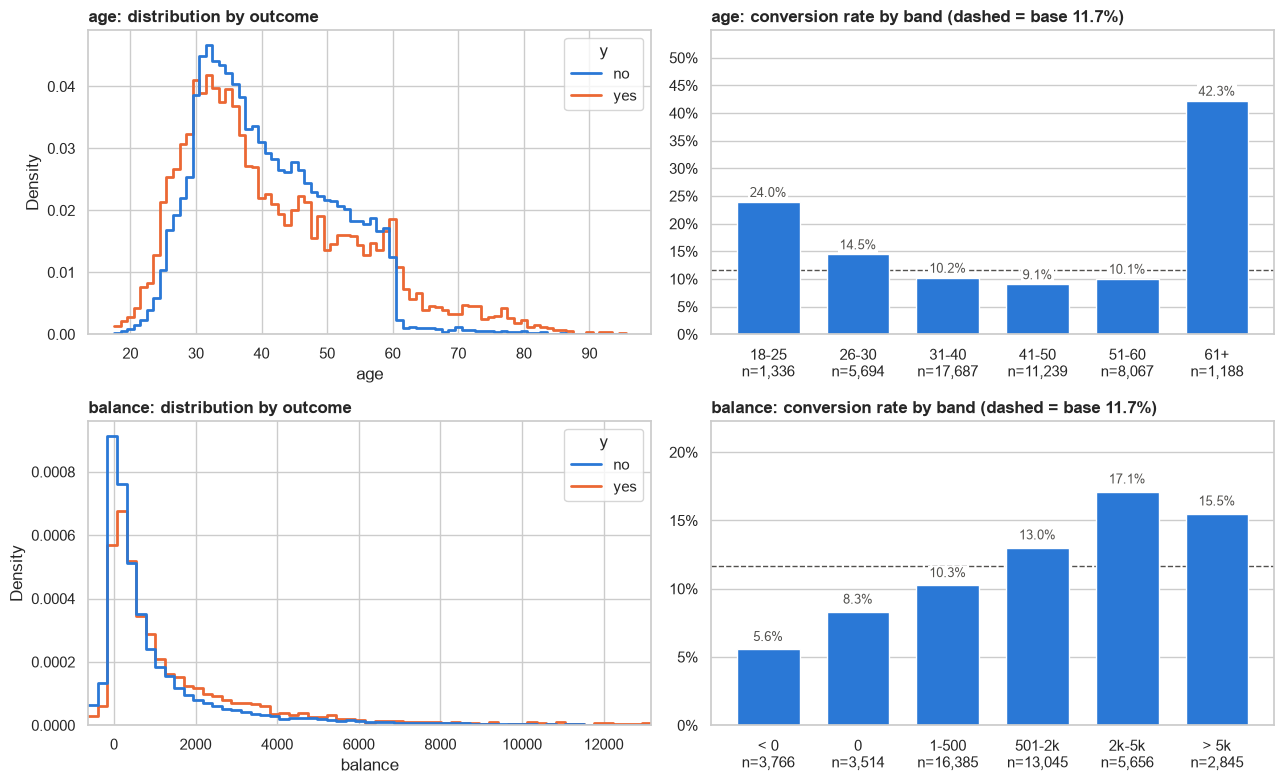

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
views = [
    ("age", "age_band", None),
    # 99% of clients sit inside this range. The long tail would squash the plot
    ("balance", "balance_band", df["balance"].quantile([0.01, 0.99]).to_numpy()),
]

for row, (col, band, xlim) in enumerate(views):
    dist_ax, rate_ax = axes[row]

    # Left: shape of the distribution for each outcome, each normalised to its own total
    sns.histplot(
        data=df, x=col, hue=TARGET, hue_order=["no", "yes"], palette=OUTCOME_COLORS,
        stat="density", common_norm=False, element="step", fill=False, linewidth=2,
        # age is whole years, so one bin per year. Balance gets 60 even bins
        **({"bins": np.linspace(*xlim, 60)} if xlim is not None else {"discrete": True}), ax=dist_ax,
    )
    if xlim is not None:
        dist_ax.set_xlim(xlim)
    dist_ax.set_title(f"{col}: distribution by outcome", loc="left", fontweight="bold")
    dist_ax.set_ylabel("Density")

    # Right: conversion rate in each band
    rates = rate_by(df[band])
    tick_labels = [f"{b}\nn={n:,}" for b, n in zip(rates.index, rates["clients"])]
    rate_ax.bar(tick_labels, rates["conversion_rate"], color="#2a78d6", width=0.7)
    rate_ax.axhline(base_rate, color="#52514e", linestyle="--", linewidth=1, zorder=0)
    for x, rate in enumerate(rates["conversion_rate"]):
        rate_ax.text(x, rate + 0.004, f"{rate:.1%}", ha="center", va="bottom", fontsize=9,
                     color="#52514e", bbox={"facecolor": "white", "edgecolor": "none", "pad": 1})
    rate_ax.set_ylim(0, rates["conversion_rate"].max() * 1.3)
    rate_ax.yaxis.set_major_locator(MultipleLocator(0.05))
    rate_ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    rate_ax.set_title(f"{col}: conversion rate by band (dashed = base {base_rate:.1%})",
                      loc="left", fontweight="bold")
    rate_ax.set_xlabel("")
    rate_ax.grid(axis="x", visible=False)

fig.tight_layout()
plt.show()


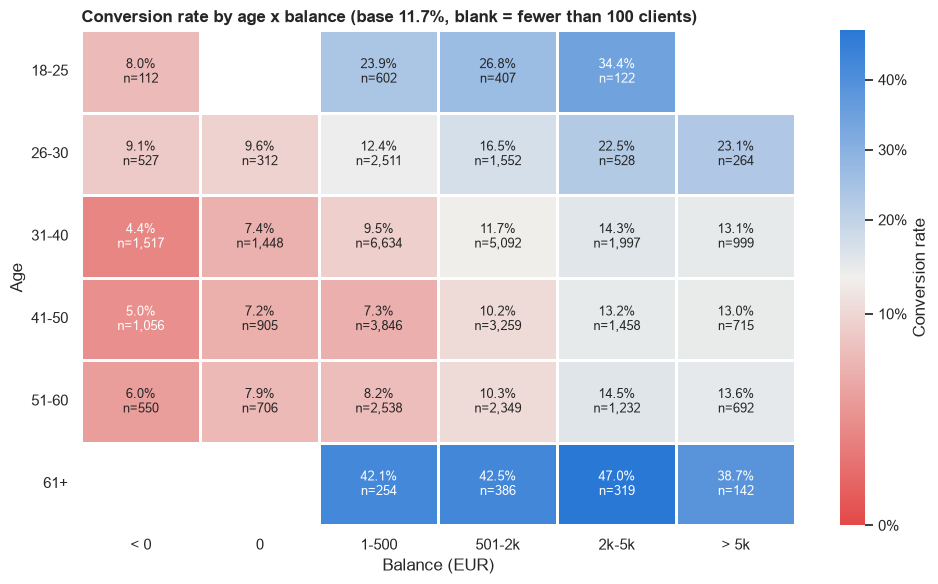

In [10]:
cross = rate_by([df["age_band"], df["balance_band"]])
rate_grid = cross["conversion_rate"].unstack()
count_grid = cross["clients"].unstack()

MIN_CLIENTS = 100  # below this a rate is too noisy to read
rate_grid = rate_grid.where(count_grid >= MIN_CLIENTS)

# Diverging around the base rate: blue = above average, red = below, grey = average
cmap = LinearSegmentedColormap.from_list("lift", ["#e34948", "#f0efec", "#2a78d6"])
norm = TwoSlopeNorm(vmin=0, vcenter=base_rate, vmax=rate_grid.max().max())

labels = (rate_grid.map(lambda r: "" if pd.isna(r) else f"{r:.1%}")
          + "\n" + count_grid.map(lambda n: f"n={n:,}"))

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(rate_grid, annot=labels, fmt="", cmap=cmap, norm=norm, linewidths=2, linecolor="white",
            annot_kws={"fontsize": 9},
            cbar_kws={"label": "Conversion rate", "format": PercentFormatter(1.0, decimals=0)}, ax=ax)
ax.set_title(f"Conversion rate by age x balance (base {base_rate:.1%}, blank = fewer than {MIN_CLIENTS} clients)",
             loc="left", fontweight="bold")
ax.set_xlabel("Balance (EUR)")
ax.set_ylabel("Age")
ax.tick_params(axis="y", rotation=0)
ax.grid(False)
fig.tight_layout()
plt.show()


### Loans and default

Clients with a housing loan, a personal loan or a default convert about half as much.

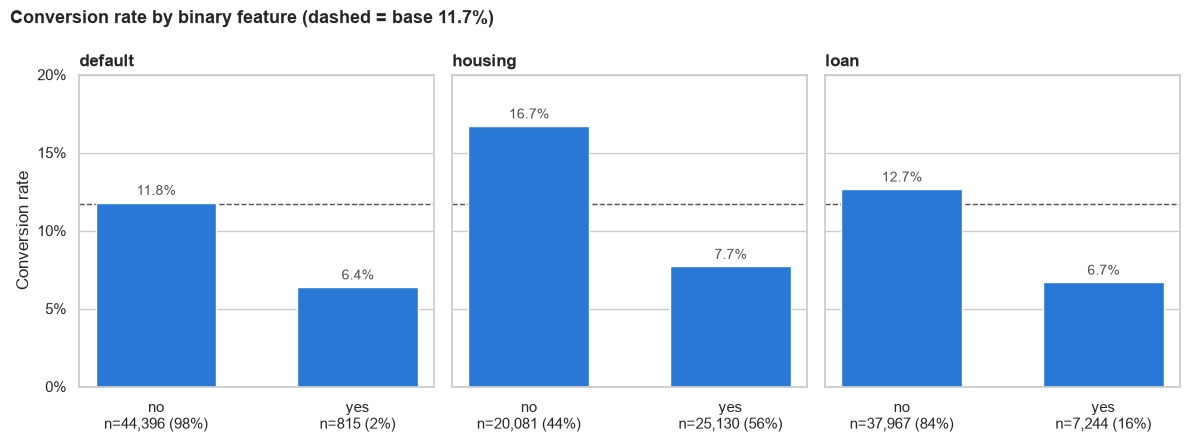

In [11]:
BINARY = ["default", "housing", "loan"]

fig, axes = plt.subplots(1, len(BINARY), figsize=(12, 4.5), sharey=True)

for ax, col in zip(axes, BINARY):
    rates = rate_by(df[col]).reindex(["no", "yes"])  # same order in every panel
    tick_labels = [f"{value}\nn={n:,} ({n / len(df):.0%})" for value, n in zip(rates.index, rates["clients"])]
    ax.bar(tick_labels, rates["conversion_rate"], color="#2a78d6", width=0.6)
    ax.axhline(base_rate, color="#52514e", linestyle="--", linewidth=1, zorder=0)
    for x, rate in enumerate(rates["conversion_rate"]):
        ax.text(x, rate + 0.003, f"{rate:.1%}", ha="center", va="bottom", fontsize=10,
                color="#52514e", bbox={"facecolor": "white", "edgecolor": "none", "pad": 1})
    ax.set_title(col, loc="left", fontweight="bold")
    ax.grid(axis="x", visible=False)

axes[0].set_ylim(0, 0.20)  # headroom so the top label clears the frame
axes[0].yaxis.set_major_locator(MultipleLocator(0.05))
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
axes[0].set_ylabel("Conversion rate")
fig.suptitle(f"Conversion rate by binary feature (dashed = base {base_rate:.1%})",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


### Past campaigns

`pdays`, `previous` and `poutcome` describe the same never contacted clients. A success in the last campaign converts at 65%.

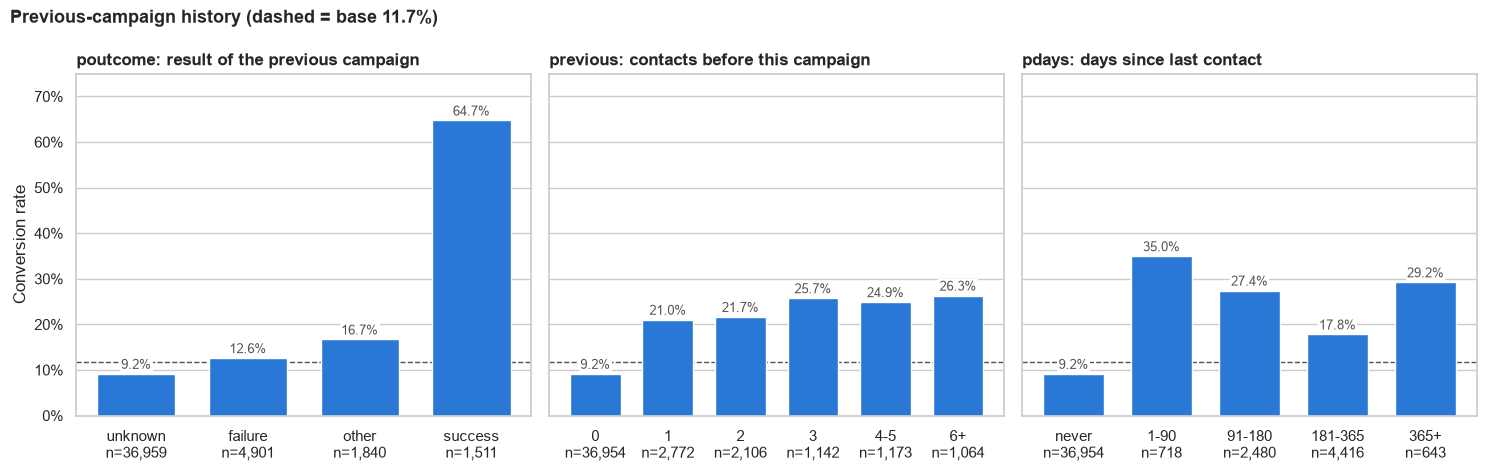

In [12]:
df["previous_band"] = pd.cut(df["previous"], [-1, 0, 1, 2, 3, 5, np.inf],
                             labels=["0", "1", "2", "3", "4-5", "6+"])
df["pdays_band"] = pd.cut(df["pdays"], [-np.inf, -1, 90, 180, 365, np.inf],
                          labels=["never", "1-90", "91-180", "181-365", "365+"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
plot_rates(axes[0], rate_by(df["poutcome"]).reindex(["unknown", "failure", "other", "success"]),
           "poutcome: result of the previous campaign")
plot_rates(axes[1], rate_by(df["previous_band"]), "previous: contacts before this campaign")
plot_rates(axes[2], rate_by(df["pdays_band"]), "pdays: days since last contact")
axes[0].set_ylim(0, 0.75)
axes[0].set_ylabel("Conversion rate")
fig.suptitle(f"Previous-campaign history (dashed = base {base_rate:.1%})", x=0.01, ha="left",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

### This campaign's calls

`duration` is leakage. It only exists after the call, so it can't be used to pick the list. More calls in the same campaign means lower conversion.

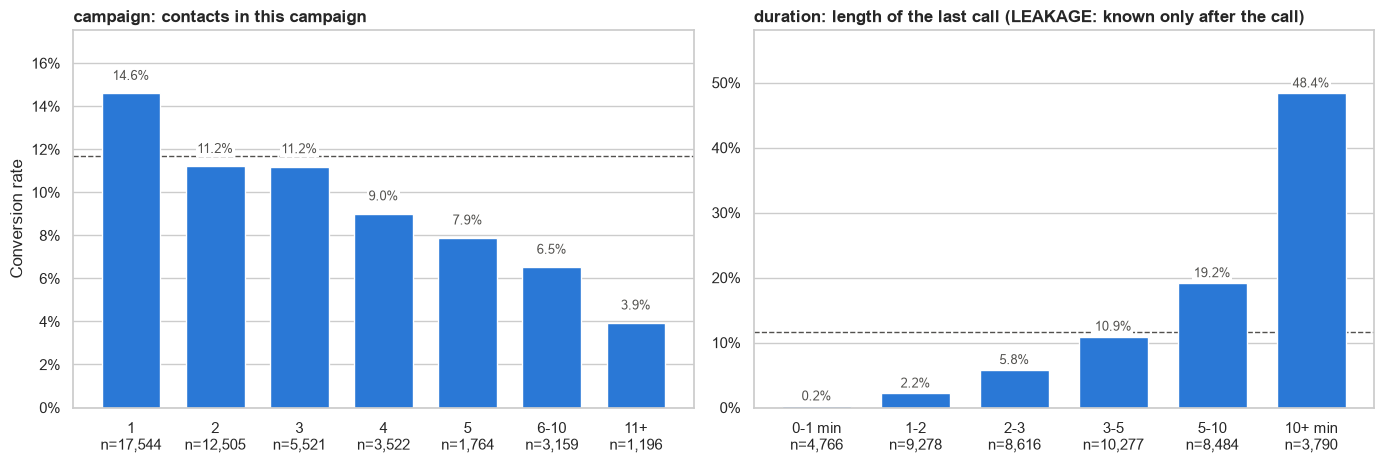

In [13]:
df["campaign_band"] = pd.cut(df["campaign"], [0, 1, 2, 3, 4, 5, 10, np.inf],
                             labels=["1", "2", "3", "4", "5", "6-10", "11+"])
df["duration_band"] = pd.cut(df["duration"], [-1, 60, 120, 180, 300, 600, np.inf],
                             labels=["0-1 min", "1-2", "2-3", "3-5", "5-10", "10+ min"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
plot_rates(axes[0], rate_by(df["campaign_band"]), "campaign: contacts in this campaign")
plot_rates(axes[1], rate_by(df["duration_band"]),
           "duration: length of the last call (LEAKAGE: known only after the call)")
axes[0].set_ylabel("Conversion rate")
fig.tight_layout()
plt.show()

### Calendar

May has the most calls and the worst rate. Months with few calls convert a lot more. This can be who the bank called in each month and not the month itself.

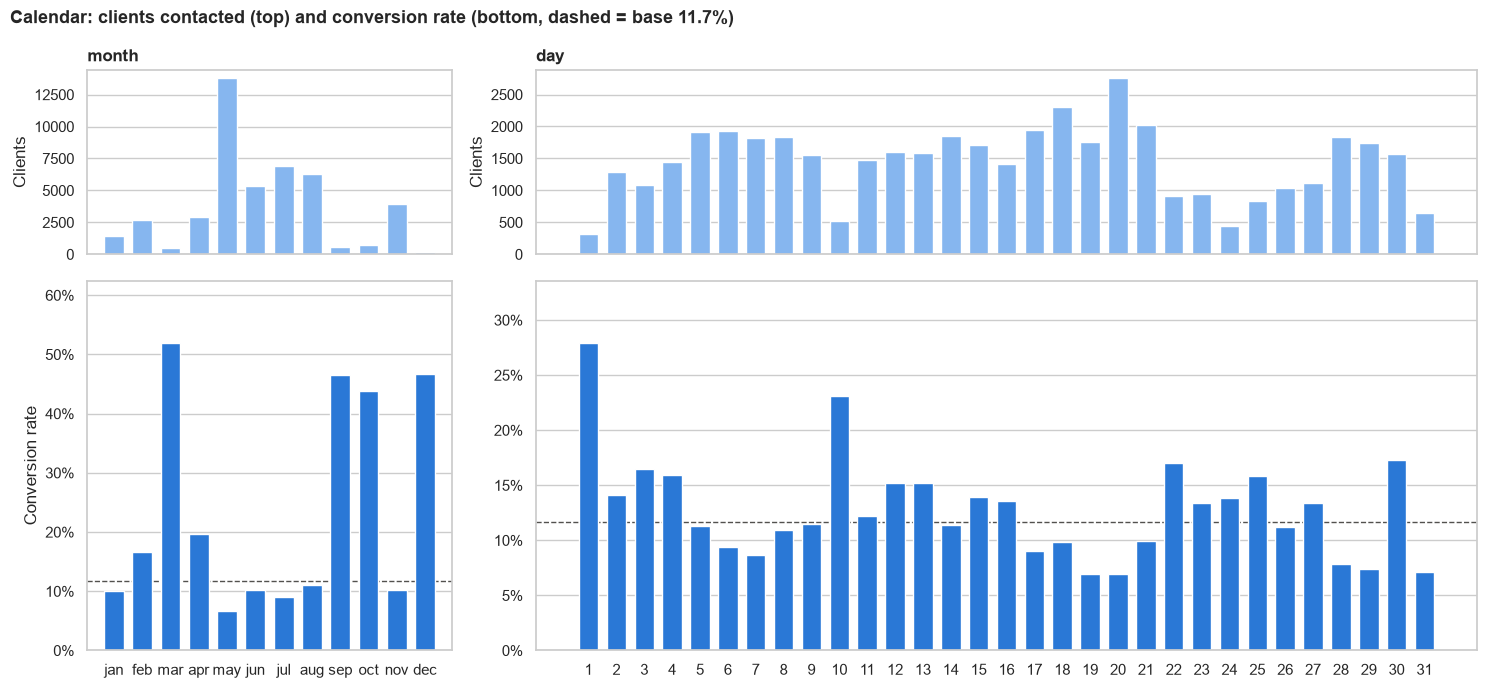

In [14]:
MONTHS = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

# Two measures with different scales -> two rows, never a second y-axis
fig, axes = plt.subplots(2, 2, figsize=(15, 7), sharex="col",
                         gridspec_kw={"width_ratios": [12, 31], "height_ratios": [1, 2]})
for col, (feature, order) in enumerate([("month", MONTHS), ("day", range(1, 32))]):
    rates = rate_by(df[feature]).reindex(order)
    count_ax, rate_ax = axes[0, col], axes[1, col]
    count_ax.bar([str(g) for g in rates.index], rates["clients"], color="#86b6ef", width=0.7)
    count_ax.set_title(feature, loc="left", fontweight="bold")
    count_ax.set_ylabel("Clients")
    count_ax.grid(axis="x", visible=False)
    plot_rates(rate_ax, rates, "", show_n=False)
axes[1, 0].set_ylabel("Conversion rate")
fig.suptitle(f"Calendar: clients contacted (top) and conversion rate (bottom, dashed = base {base_rate:.1%})",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

### Young and 61+ clients

Do they convert more because of the age, the job or because they were contacted before? Even never contacted, 61+ converts at 38% and 18-25 at 22%. For 61+ it is the age, retired or not. For young clients being a student also matters.

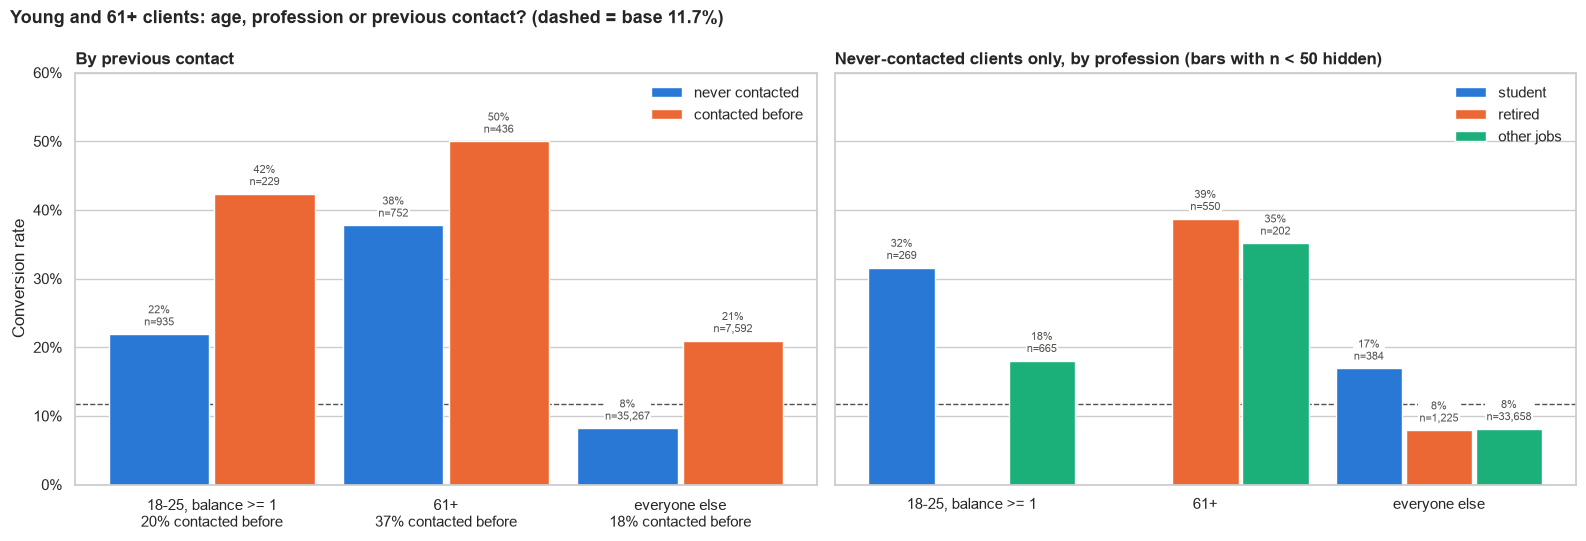

In [15]:
SEGMENTS = ["18-25, balance >= 1", "61+", "everyone else"]
segment = pd.Series(
    np.select([(df["age"] <= 25) & (df["balance"] >= 1), df["age"] > 60], SEGMENTS[:2], SEGMENTS[2]),
    index=df.index,
)
history = df["previous"].gt(0).map({False: "never contacted", True: "contacted before"})
job_group = df["job"].where(df["job"].isin(["student", "retired"]), "other jobs")

def grouped_bars(ax, rates, counts, colors, min_n=50):
    """One group of bars per segment (rows), one bar per series (columns)."""
    width = 0.9 / len(rates.columns)
    for i, series in enumerate(rates.columns):
        x = np.arange(len(rates)) + (i - (len(rates.columns) - 1) / 2) * width
        values = rates[series].where(counts[series] >= min_n)  # hide noisy rates
        ax.bar(x, values, width * 0.95, color=colors[i], label=series)
        for xi, rate, n in zip(x, values, counts[series]):
            if pd.notna(rate):
                ax.text(xi, rate + 0.008, f"{rate:.0%}\nn={n:,}", ha="center", va="bottom", fontsize=8,
                        color="#52514e", bbox={"facecolor": "white", "edgecolor": "none", "pad": 1})
    ax.set_xticks(range(len(rates)), rates.index)
    ax.axhline(base_rate, color="#52514e", linestyle="--", linewidth=1, zorder=0)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper right", frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)

# Left: does prior contact explain the segment's rate?
stats = converted.groupby([segment, history]).agg(["mean", "size"]).unstack()
cols = ["never contacted", "contacted before"]
share_before = df["previous"].gt(0).groupby(segment).mean()
grouped_bars(axes[0], stats["mean"][cols].reindex(SEGMENTS), stats["size"][cols].reindex(SEGMENTS),
             ["#2a78d6", "#eb6834"])
axes[0].set_xticks(range(len(SEGMENTS)), [f"{s}\n{share_before[s]:.0%} contacted before" for s in SEGMENTS])
axes[0].set_title("By previous contact", loc="left", fontweight="bold")
axes[0].set_ylabel("Conversion rate")

# Right: among never-contacted clients only, is it age or profession?
never = history.eq("never contacted")
stats = converted[never].groupby([segment[never], job_group[never]]).agg(["mean", "size"]).unstack()
cols = ["student", "retired", "other jobs"]
grouped_bars(axes[1], stats["mean"][cols].reindex(SEGMENTS),
             stats["size"][cols].reindex(SEGMENTS).fillna(0).astype(int),
             ["#2a78d6", "#eb6834", "#1baf7a"])
axes[1].set_title("Never-contacted clients only, by profession (bars with n < 50 hidden)", loc="left",
                  fontweight="bold")

axes[0].set_ylim(0, 0.6)
fig.suptitle(f"Young and 61+ clients: age, profession or previous contact? (dashed = base {base_rate:.1%})",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

### Association between all columns

Each pair uses the measure that fits the column types. These measures only see straight line patterns, so age looks weak here even with the U shape.

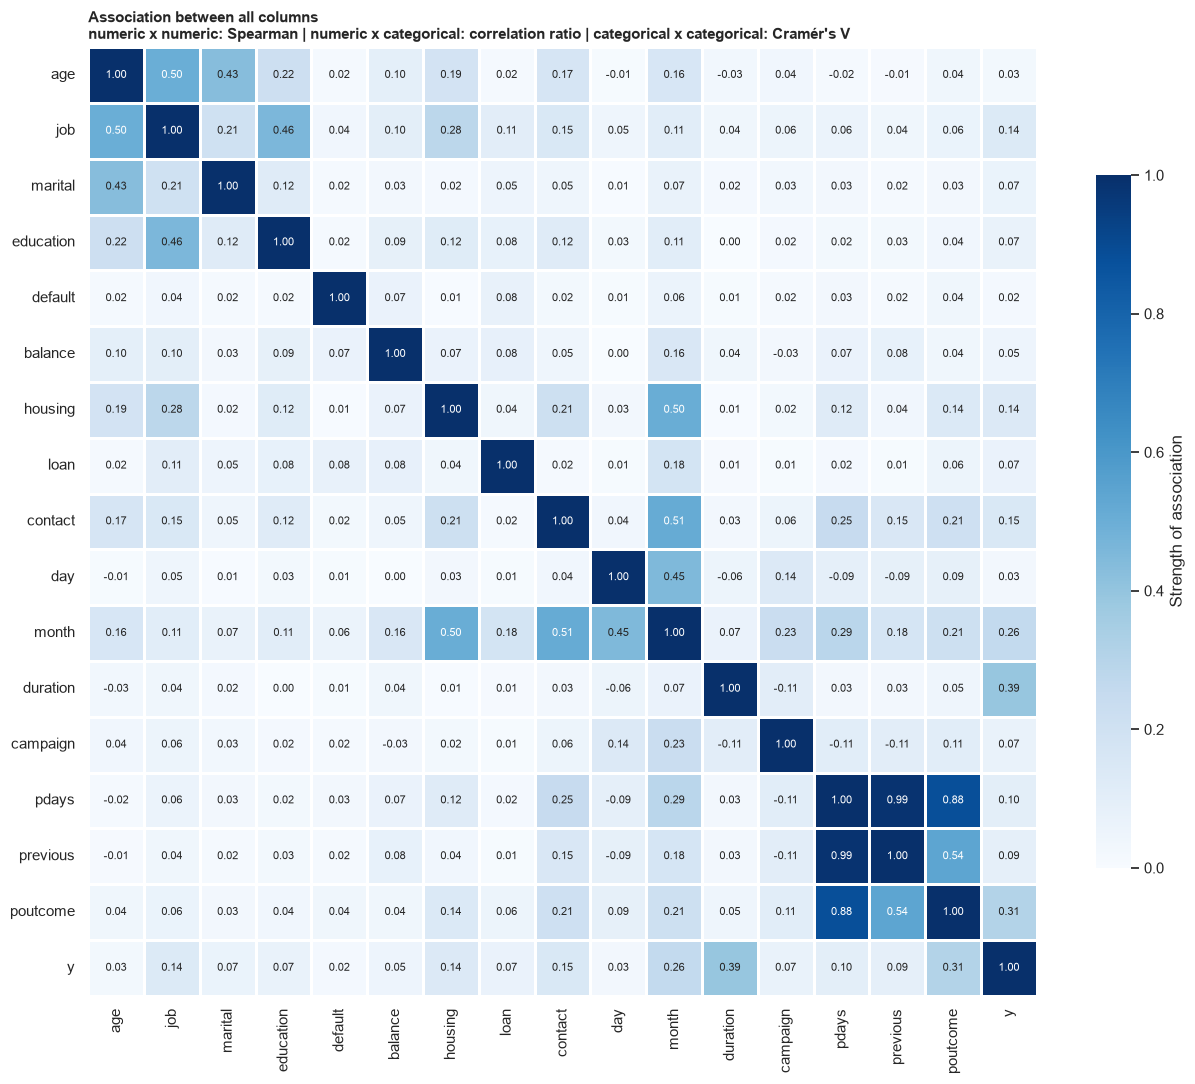

duration     0.395
poutcome     0.312
month        0.260
contact      0.151
housing      0.139
job          0.136
pdays        0.104
previous     0.093
campaign     0.073
education    0.073
loan         0.068
marital      0.066
balance      0.053
day          0.028
age          0.025
default      0.022
Name: y, dtype: float64

In [16]:
# Use only the original columns, not the *_band helpers created above
COLUMNS = pd.read_csv(RAW_PATH, sep=SEP, nrows=0).columns.tolist()
NUMERIC = df[COLUMNS].select_dtypes("number").columns.tolist()

def correlation_ratio(categories, values):
    """Eta: share of a numeric column's spread explained by a categorical column (0 to 1)."""
    group_means = values.groupby(categories).transform("mean")
    return np.sqrt(((group_means - values.mean()) ** 2).sum() / ((values - values.mean()) ** 2).sum())

def pair_association(a, b):
    if a in NUMERIC and b in NUMERIC:
        return df[a].corr(df[b], method="spearman")               # -1 to 1, keeps direction
    if a in NUMERIC or b in NUMERIC:
        num, cat = (a, b) if a in NUMERIC else (b, a)
        return correlation_ratio(df[cat], df[num])                 # 0 to 1
    return association(pd.crosstab(df[a], df[b]), method="cramer")  # 0 to 1

assoc = pd.DataFrame(1.0, index=COLUMNS, columns=COLUMNS)
for a, b in combinations(COLUMNS, 2):
    assoc.loc[a, b] = assoc.loc[b, a] = pair_association(a, b)

# Colour by strength. The number keeps the sign where one exists (numeric vs numeric)
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(assoc.abs(), annot=assoc, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True,
            linewidths=1, linecolor="white", annot_kws={"fontsize": 8},
            cbar_kws={"label": "Strength of association", "shrink": 0.7}, ax=ax)
ax.set_title("Association between all columns\n"
             "numeric x numeric: Spearman | numeric x categorical: correlation ratio | "
             "categorical x categorical: Cramér's V",
             loc="left", fontweight="bold", fontsize=11)
ax.grid(False)
fig.tight_layout()
plt.show()

# Strongest links with the target
assoc[TARGET].drop(TARGET).sort_values(ascending=False).round(3)

### Causal DAG

`duration`, `day`, `month` and `campaign` are out because they describe the calls of this campaign and not the client.

FCI finds the links from the data, using only the time order as prior knowledge. Then I decide the edges it can't orient:

- education causes job and marital, and job causes marital
- default causes balance (FCI ruled out balance causing default)
- loan, balance and housing have a hidden common cause, the client's financial needs

In [17]:
# Causal discovery with FCI: learns the links from the data, allowing for hidden common causes.
# Time order is the only prior knowledge: an arrow can never point to an earlier tier.
# pdays and previous are left out: both are fully determined by poutcome == "unknown"
# (never contacted), and exact duplicates break the independence tests FCI relies on.
TIERS = [
    ["age"],
    ["education", "job", "marital"],
    ["balance", "housing", "loan", "default"],
    ["poutcome"],
    ["contact"],
    [TARGET],
]
FCI_COLUMNS = [col for tier in TIERS for col in tier]

# With 45k rows almost any tiny link is "significant", so the threshold is very strict.
# Results change with it (1e-5 also links age, education and loan to y, 1e-20 drops job and marital).
ALPHA = 1e-10

# The G-test needs categories: numeric columns become 5 quantile bins
discrete = pd.DataFrame({
    col: (pd.qcut(df[col], 5, duplicates="drop") if pd.api.types.is_numeric_dtype(df[col]) else df[col])
    .factorize()[0]
    for col in FCI_COLUMNS
})

nodes = {col: GraphNode(col) for col in FCI_COLUMNS}
knowledge = BackgroundKnowledge()
for tier, cols in enumerate(TIERS):
    for col in cols:
        knowledge.add_node_to_tier(nodes[col], tier)

# redirect_stdout hides the library's long orientation log
with contextlib.redirect_stdout(io.StringIO()):
    pag, _ = fci(discrete.to_numpy(), independence_test_method="gsq", alpha=ALPHA, depth=2,
                 background_knowledge=knowledge, node_names=FCI_COLUMNS, show_progress=False)

print(f"{len(pag.get_graph_edges())} edges found")

29 edges found


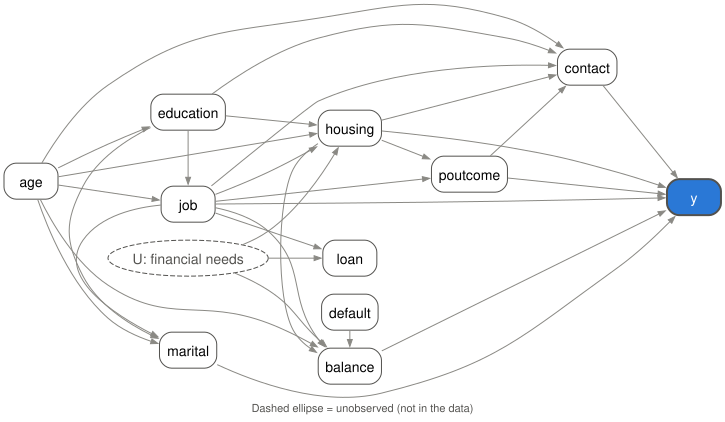

In [18]:
# FCI edge ends: arrow = "points into", tail = "causes", circle = "can't tell"
ARROWHEADS = {"ARROW": "normal", "TAIL": "none", "CIRCLE": "odot"}
found = {}
for edge in pag.get_graph_edges():
    a, b = edge.get_node1().get_name(), edge.get_node2().get_name()
    found[frozenset((a, b))] = (a, b, ARROWHEADS[edge.get_endpoint1().name], ARROWHEADS[edge.get_endpoint2().name])

# Final DAG: every link FCI found, with the undecided ends resolved by hand.
# Edges with a circle ("direction unknown") must be decided here, otherwise the cell stops.
DECISIONS = [
    ("education", "job"),
    ("education", "marital"),
    ("job", "marital"),
    ("default", "balance"),  # FCI ruled out balance -> default (arrowhead at balance)
]
# Arrows at both ends = a hidden common cause: drawn as one unobserved node
HIDDEN_CAUSE = "U_finance"  # plain id: graphviz reads ":" as a port

decided = {frozenset(pair): pair for pair in DECISIONS}
final_edges = []
for pair, (a, b, tail, head) in found.items():
    if pair in decided:
        final_edges.append(decided[pair])
    elif tail == "normal" and head == "normal":
        final_edges += [(HIDDEN_CAUSE, a), (HIDDEN_CAUSE, b)]
    elif tail == "none" and head == "normal":
        final_edges.append((a, b))
    elif tail == "normal" and head == "none":
        final_edges.append((b, a))
    else:
        raise ValueError(f"Decide the direction of {a} - {b} and add it to DECISIONS")
final_edges = list(dict.fromkeys(final_edges))  # drop duplicates, keep order

final_dag = gr.Digraph(graph_attr={"rankdir": "LR", "fontname": "Helvetica", "nodesep": "0.25", "ranksep": "0.7",
                                   "label": "Dashed ellipse = unobserved (not in the data)",
                                   "labelloc": "b", "fontsize": "11", "fontcolor": "#52514e"})
final_dag.attr("node", shape="box", style="rounded", color="#52514e", fontname="Helvetica")
final_dag.attr("edge", color="#8a8984", arrowsize="0.7")

for cols in TIERS:
    with final_dag.subgraph() as tier:  # each time tier in its own column
        tier.attr(rank="same")
        for col in cols:
            tier.node(col)
final_dag.node(TARGET, style="rounded,filled,bold", fillcolor="#2a78d6", fontcolor="white")
final_dag.node(HIDDEN_CAUSE, "U: financial needs", shape="ellipse", style="dashed", fontcolor="#52514e")

for tail, head in final_edges:
    final_dag.edge(tail, head)

final_dag

### What this EDA leaves settled

1. The base rate is 11.7%. A random list of 3,000 calls gives about 351 conversions. That is the floor.
2. `duration` is leakage and stays out. `day`, `month` and `campaign` are also out because they describe this campaign's calls.
3. The segments that stand out: age (18-25 and 61+), success in the last campaign, no housing loan, higher balance and a known contact channel.